In [113]:
# ─── Temel veri işleme kütüphaneleri ───────────────────────────────────────
import numpy as np          # Sayısal hesaplamalar (dizi işlemleri, lineer cebir)
import pandas as pd         # Tablo (DataFrame) yapısında veri işleme
import matplotlib.pyplot as plt  # Grafik çizimi
import seaborn as sns       # matplotlib üzerine kurulu, daha şık görselleştirme
import warnings
warnings.filterwarnings('ignore')  # Gereksiz uyarıları gizle
from sklearn.preprocessing import LabelEncoder

# ─── Scikit-learn araçları ──────────────────────────────────────────────────
from sklearn.datasets import make_classification, load_breast_cancer
# load_breast_cancer : 569 örnek, 30 özellik içeren gerçek tıbbi veri seti

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
# train_test_split : veriyi eğitim / test olarak böler
# cross_val_score  : k-fold çapraz doğrulama skoru
# learning_curve   : farklı eğitim boyutlarında performans eğrisi

from sklearn.ensemble import AdaBoostClassifier
# AdaBoost sınıflandırıcı — sklearn içinde hazır gelir

from sklearn.tree import DecisionTreeClassifier
# AdaBoost'un zayıf öğrenicisi olarak kullanılacak karar ağacı

from sklearn.preprocessing import StandardScaler
# Özellikleri ortalaması 0, std'si 1 olacak şekilde ölçekler

from sklearn.metrics import (
    accuracy_score,         # Doğru tahmin oranı
    classification_report,  # Precision / Recall / F1 özet tablosu
    confusion_matrix,       # Hangi sınıf hangisiyle karıştırıldı?
    roc_auc_score,          # ROC eğrisinin altındaki alan (0.5=rastgele, 1=mükemmel)
    roc_curve,              # FPR ve TPR değerleri (ROC grafiği için)
    f1_score,               # Precision ve Recall'ın harmonik ortalaması
    precision_score,        # TP / (TP + FP) — "Tahmin ettiklerimin kaçı doğru?"
    recall_score            # TP / (TP + FN) — "Gerçeklerin kaçını yakaladım?"
)

import xgboost as xgb      # XGBoost kütüphanesi (pip install xgboost)
import time                 # Eğitim süresi ölçümü için

# ─── Görsel ayarlar ─────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)      # Varsayılan grafik boyutu
plt.rcParams['font.size'] = 12                # Varsayılan yazı boyutu
plt.style.use('seaborn-v0_8-whitegrid')       # Beyaz ızgara temalı stil

print('✅ Tüm kütüphaneler başarıyla yüklendi!')
print(f'   XGBoost versiyonu: {xgb.__version__}')

✅ Tüm kütüphaneler başarıyla yüklendi!
   XGBoost versiyonu: 3.2.0


In [114]:
# VERİYİ YÜKLE
df = pd.read_csv('/content/sample_data/student_mental_health_burnout.csv')
df.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


1. X ve y nasıl ayrılır?

Genel kural:

X = input özellikler (features)

y = tahmin etmek istediğin hedef (label)

X = df.drop(columns=['TARGET_SUTUNU'])  # hedef hariç her şey

y = df['TARGET_SUTUNU']

In [115]:
print(df.isnull().sum())
#print(y.isnull().sum())

student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64


In [116]:
#Model bölme işlemine geçmeden önce veri temiz olmalı.
df = df.dropna()

In [117]:
# X ve y AYIR
X = df.drop(columns=['burnout_level','student_id'])  # hedef hariç her şey
y = df['burnout_level']

In [118]:
# KATEGORİK FEATURE'LARI SAYISALA ÇEVİR
X = pd.get_dummies(X, drop_first=True)

Burada çözdüğümüz problem şu:

> ML modelleri metin/string verilerle matematik yapamaz.

Senin verinde şöyle sütunlar vardı:

```python id="iwrh2h"
gender
course
stress_level
sleep_quality
internet_quality
```

Ve bunların tipi:

```python id="jlwmg4"
object
```

yani yazı/metin.

---

# ❌ Problem neydi?

Model şunu anlayamaz:

```python id="x9k1ub"
"Male"
"Female"
```

Çünkü model arka planda:

* toplama
* bölme
* eşik belirleme
* impurity hesabı

gibi matematiksel işlemler yapıyor.

---

# ✅ `get_dummies()` ne yaptı?

Şunu yaptı:

## Önce:

| gender |
| ------ |
| Male   |
| Female |
| Male   |

---

## Sonra:

| gender_Male |
| ----------- |
| 1           |
| 0           |
| 1           |

---

Yani:

* kategori → sayısal sütun

dönüşümü yaptı.

---

# 🧠 Çok önemli fikir

Bu işlem aslında:

> “Bu kategori var mı?”
> sorusunu 0/1 şeklinde temsil ediyor.

---

# 🔥 Peki `drop_first=True` neden kullandık?

Örneğin:

```python id="8cdqti"
Male
Female
```

için iki sütun oluşturmaya gerek yok:

| Male | Female |
| ---- | ------ |
| 1    | 0      |
| 0    | 1      |

Çünkü biri zaten diğerini belirliyor.

---

## Bunun yerine:

| Male |
| ---- |
| 1    |
| 0    |

yeterli.

---

# 🚀 Böylece ne kazanıyoruz?

* gereksiz feature azalır
* multicollinearity azalır
* model daha verimli çalışır

---

# 💡 Senin verinde örnek

Mesela:

```python id="m4t6e0"
sleep_quality
```

şunlara dönüşebilir:

```python id="34u1t7"
sleep_quality_Good
sleep_quality_Poor
sleep_quality_Average
```

ve bunlar:

* 0
* 1

olarak tutulur.

---

# 🔥 Kısaca özet

```python id="1l02ef"
pd.get_dummies()
```

👉 kategorik/string verileri
👉 modelin anlayabileceği sayısal 0/1 formatına çevirir.


In [119]:
# TARGET ENCODING
# High -> 0
# Low -> 1
# Medium -> 2

le = LabelEncoder()
y = le.fit_transform(y)

XGBoost ve AdaBoost genelde sayısal label ister.

| Eski   | Yeni |
| ------ | ---- |
| High   | 0    |
| Low    | 1    |
| Medium | 2    |


ML modelleri matematik yaptığı için:

string anlamaz
sayıya çevirmek gerekir

Ama:

model “High > Medium > Low” ilişkisini gerçekten anlamıyor

Sadece:

0
1
2

olarak görüyor.

Bu yüzden bazen:

Label Encoding
One Hot Encoding

arasındaki fark çok kritik olur.

In [120]:
print('📋 Veri Seti Bilgileri')
print('='*40)
print(f'Özellik sayısı  : {X.shape[1]}')
print(f'Örnek sayısı    : {X.shape[0]}')
# numpy array olduğu için:
unique, counts = np.unique(y, return_counts=True)
print('Sınıf dağılımı:')
for cls, count in zip(unique, counts):
    print(f'  {cls} ({le.classes_[cls]}) : {count}')

print()

📋 Veri Seti Bilgileri
Özellik sayısı  : 28
Örnek sayısı    : 150000
Sınıf dağılımı:
  0 (High) : 49766
  1 (Low) : 50265
  2 (Medium) : 49969



In [121]:
# TRAIN / TEST SPLIT
# ─────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('\n📦 Veri Bölme')
print('='*40)
print(f'Eğitim seti : {X_train.shape[0]}')
print(f'Test seti   : {X_test.shape[0]}')



📦 Veri Bölme
Eğitim seti : 120000
Test seti   : 30000


Bu soru aslında işin “mantığını gerçekten kavradın mı?” kısmı — çok iyi bir noktaya geldin.

Kafa karıştıran şey şu:

> “Modeli hedef olmadan eğitiyorsak, nasıl doğru tahmin yapıyor?”

Cevap: **Eğitim sırasında hedef aslında var — sadece input olarak verilmez.**

---

# 🧠 1. X ve y aslında ne oluyor?

Sen şunu yapıyorsun:

```python
X = df.drop(columns=['target'])
y = df['target']
```

Bunu iki ayrı şey gibi düşün:

### 📦 X (girdi)

Modelin gördüğü bilgiler:

* stres seviyesi
* uyku süresi
* ders saati
* vs.

### 🎯 y (gerçek cevap)

Modelin öğrenmeye çalıştığı şey:

* burnout var mı? (0/1)

---

# 🧠 2. train_test_split aslında ne yapıyor?

```python
X_train, X_test, y_train, y_test = train_test_split(X, y)
```

Bu şu demek:

| Veri    | İçerik                |
| ------- | --------------------- |
| X_train | özellikler            |
| y_train | doğru cevaplar        |
| X_test  | sadece özellikler     |
| y_test  | sadece doğru cevaplar |

---

# 🔥 3. Model nasıl öğreniyor?

Şu satır kritik:

```python
model.fit(X_train, y_train)
```

Burada model şunu yapıyor:

👉 “X_train → y_train ilişkisini öğren”

Örnek gibi düşün:

| Uyku   | Ders   | Sonuç       |
| ------ | ------ | ----------- |
| 3 saat | çok    | 1 (burnout) |
| 8 saat | normal | 0           |

Model bu pattern’i öğreniyor.

---

# 🧠 4. Testte ne oluyor?

```python
y_pred = model.predict(X_test)
```

Burada:

* Model sadece **X_test görüyor**
* Ama **y_test görmüyor**

Model şunu yapıyor:

> “Bu özellikleri daha önce gördüğüm patternlere benziyor → o zaman tahmin = 1/0”

---

# ⚡ 5. En önemli fikir (core mantık)

Model aslında şunu yapıyor:

### ❌ yanlış düşünce:

> “Hedef olmadan öğreniyor”

### ✅ doğru düşünce:

> “Hedefi öğrenme aşamasında kullanıyor, testte ise saklıyor”

---

# 🧠 6. Basit benzetme

Bir öğrenci gibi düşün:

### 📚 Eğitim:

* Soru + cevapları görür
* Ezber değil, pattern öğrenir

### 📝 Sınav:

* Sadece soruları görür
* Cevabı tahmin eder

---

# 🚀 7. Neden y testte verilmiyor?

Çünkü:

👉 Eğer testte y verilseydi:

* model “hile yapmış” olurdu
* performans ölçemezdin

Test seti = gerçek dünya simülasyonu

---

# 🔥 8. Özet (tek cümle)

Model:

> “Eğitimde X → y ilişkisini öğrenir, testte sadece X görerek öğrendiği ilişkiye göre tahmin yapar.”

---


In [122]:
print(le.classes_)

['High' 'Low' 'Medium']


| Label  | Sayı |
| ------ | ---- |
| High   | 0    |
| Low    | 1    |
| Medium | 2    |


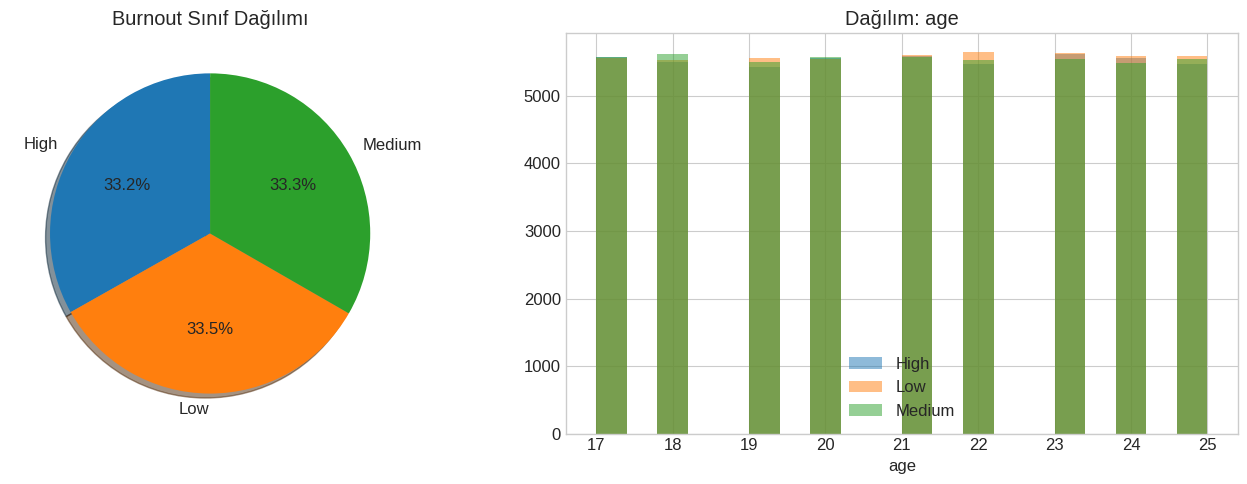

In [123]:
# GÖRSELLEŞTİRME
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------- PIE CHART ----------------
counts = pd.Series(y).value_counts().sort_index()

axes[0].pie(
    counts,
    labels=le.classes_,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True
)

axes[0].set_title('Burnout Sınıf Dağılımı')

# ---------------- HISTOGRAM ----------------
numeric_cols = X.select_dtypes(include=np.number).columns

feat = numeric_cols[0]

axes[1].hist(X[feat][y==0], alpha=0.5, label=le.classes_[0], bins=20)
axes[1].hist(X[feat][y==1], alpha=0.5, label=le.classes_[1], bins=20)
axes[1].hist(X[feat][y==2], alpha=0.5, label=le.classes_[2], bins=20)

axes[1].set_title(f'Dağılım: {feat}')
axes[1].set_xlabel(feat)
axes[1].legend()

plt.tight_layout()
plt.show()

Bu grafik aslında şunu gösterir:

👉 “Feature sınıfları ayırabiliyor mu?”

Eğer histogramlar:

üst üste → kötü feature

ayrışmış → iyi feature

In [124]:
 #ADABOOST MODELİ
# ─────────────────────────────────────────────────────────────
print('\n🔴 ADABOOST MODELİ EĞİTİLİYOR...')
print('='*45)

ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.1,
    algorithm='SAMME',
    random_state=42
)

# ---------------- EĞİTİM ----------------
start = time.time()

ada_model.fit(X_train, y_train)

ada_time = time.time() - start

# ---------------- TAHMİN ----------------
ada_pred = ada_model.predict(X_test)

# multiclass probability
ada_prob = ada_model.predict_proba(X_test)

# ─────────────────────────────────────────
# METRİKLER
# ─────────────────────────────────────────
ada_acc = accuracy_score(y_test, ada_pred)

ada_f1 = f1_score(
    y_test,
    ada_pred,
    average='weighted'
)

ada_prec = precision_score(
    y_test,
    ada_pred,
    average='weighted'
)

ada_recall = recall_score(
    y_test,
    ada_pred,
    average='weighted'
)

ada_auc = roc_auc_score(
    y_test,
    ada_prob,
    multi_class='ovr'
)

# ─────────────────────────────────────────
# SONUÇLAR
# ─────────────────────────────────────────
print(f'✅ Eğitim Süresi : {ada_time:.4f} sn')
print(f'📊 Accuracy      : {ada_acc:.4f}')
print(f'📊 AUC-ROC       : {ada_auc:.4f}')
print(f'📊 F1 Score      : {ada_f1:.4f}')
print(f'📊 Precision     : {ada_prec:.4f}')
print(f'📊 Recall        : {ada_recall:.4f}')

print('\n📋 Classification Report')
print('='*45)

print(
    classification_report(
        y_test,
        ada_pred,
        target_names=le.classes_
    )
)


🔴 ADABOOST MODELİ EĞİTİLİYOR...
✅ Eğitim Süresi : 13.6013 sn
📊 Accuracy      : 0.3351
📊 AUC-ROC       : 0.5004
📊 F1 Score      : 0.1682
📊 Precision     : 0.1123
📊 Recall        : 0.3351

📋 Classification Report
              precision    recall  f1-score   support

        High       0.00      0.00      0.00      9953
         Low       0.34      1.00      0.50     10053
      Medium       0.00      0.00      0.00      9994

    accuracy                           0.34     30000
   macro avg       0.11      0.33      0.17     30000
weighted avg       0.11      0.34      0.17     30000



In [125]:
X.dtypes

,0
age,int64
daily_study_hours,float64
daily_sleep_hours,float64
screen_time_hours,float64
anxiety_score,int64
depression_score,int64
academic_pressure_score,int64
financial_stress_score,int64
social_support_score,int64
physical_activity_hours,float64


In [128]:
# ─────────────────────────────────────────────────────────────
# XGBOOST MODELİ
# ─────────────────────────────────────────────────────────────

from xgboost import XGBClassifier

print('\n🟢 XGBOOST MODELİ EĞİTİLİYOR...')
print('='*45)

# ─────────────────────────────────────────────────────────────
# MODEL TANIMLAMA
# ─────────────────────────────────────────────────────────────
xgb_model = XGBClassifier(

    # Kaç boosting ağacı oluşturulacak?
    n_estimators=300,

    # Öğrenme hızı
    learning_rate=0.1,

    # Her ağacın maksimum derinliği
    max_depth=3,

    # Multiclass problemi olduğu için
    objective='multi:softprob',

    # Sınıf sayısı
    num_class=3,

    # Rastgelelik kontrolü
    random_state=42,

    # Evaluation metric
    eval_metric='mlogloss'

)

# ─────────────────────────────────────────────────────────────
# EĞİTİM
# ─────────────────────────────────────────────────────────────
start = time.time()

xgb_model.fit(X_train, y_train)

xgb_time = time.time() - start

# ─────────────────────────────────────────────────────────────
# TAHMİN
# ─────────────────────────────────────────────────────────────
xgb_pred = xgb_model.predict(X_test)

# Her sınıf için olasılık
xgb_prob = xgb_model.predict_proba(X_test)

# ─────────────────────────────────────────────────────────────
# PERFORMANS METRİKLERİ
# ─────────────────────────────────────────────────────────────
xgb_acc = accuracy_score(y_test, xgb_pred)

xgb_f1 = f1_score(
    y_test,
    xgb_pred,
    average='weighted'
)

xgb_prec = precision_score(
    y_test,
    xgb_pred,
    average='weighted'
)

xgb_recall = recall_score(
    y_test,
    xgb_pred,
    average='weighted'
)

xgb_auc = roc_auc_score(
    y_test,
    xgb_prob,
    multi_class='ovr'
)

# ─────────────────────────────────────────────────────────────
# SONUÇLAR
# ─────────────────────────────────────────────────────────────
print(f'✅ Eğitim Süresi : {xgb_time:.4f} sn')
print(f'📊 Accuracy      : {xgb_acc:.4f}')
print(f'📊 AUC-ROC       : {xgb_auc:.4f}')
print(f'📊 F1 Score      : {xgb_f1:.4f}')
print(f'📊 Precision     : {xgb_prec:.4f}')
print(f'📊 Recall        : {xgb_recall:.4f}')

print('\n📋 Classification Report')
print('='*45)

print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=le.classes_
    )
)


🟢 XGBOOST MODELİ EĞİTİLİYOR...
✅ Eğitim Süresi : 13.4283 sn
📊 Accuracy      : 0.3331
📊 AUC-ROC       : 0.4990
📊 F1 Score      : 0.3323
📊 Precision     : 0.3329
📊 Recall        : 0.3331

📋 Classification Report
              precision    recall  f1-score   support

        High       0.33      0.32      0.32      9953
         Low       0.34      0.38      0.36     10053
      Medium       0.33      0.30      0.32      9994

    accuracy                           0.33     30000
   macro avg       0.33      0.33      0.33     30000
weighted avg       0.33      0.33      0.33     30000



In [129]:
print(df['burnout_level'].value_counts())

burnout_level
Low       50265
Medium    49969
High      49766
Name: count, dtype: int64


In [133]:
df['burnout_level'] = le.fit_transform(df['burnout_level'])

corr = df.corr(numeric_only=True)

print(corr['burnout_level'].sort_values(ascending=False))

burnout_level              1.000000
daily_sleep_hours          0.003205
physical_activity_hours    0.003186
anxiety_score              0.001229
depression_score           0.001017
screen_time_hours          0.000833
cgpa                       0.000284
student_id                 0.000259
social_support_score       0.000226
daily_study_hours         -0.000609
attendance_percentage     -0.000755
financial_stress_score    -0.001540
age                       -0.001625
academic_pressure_score   -0.004231
Name: burnout_level, dtype: float64


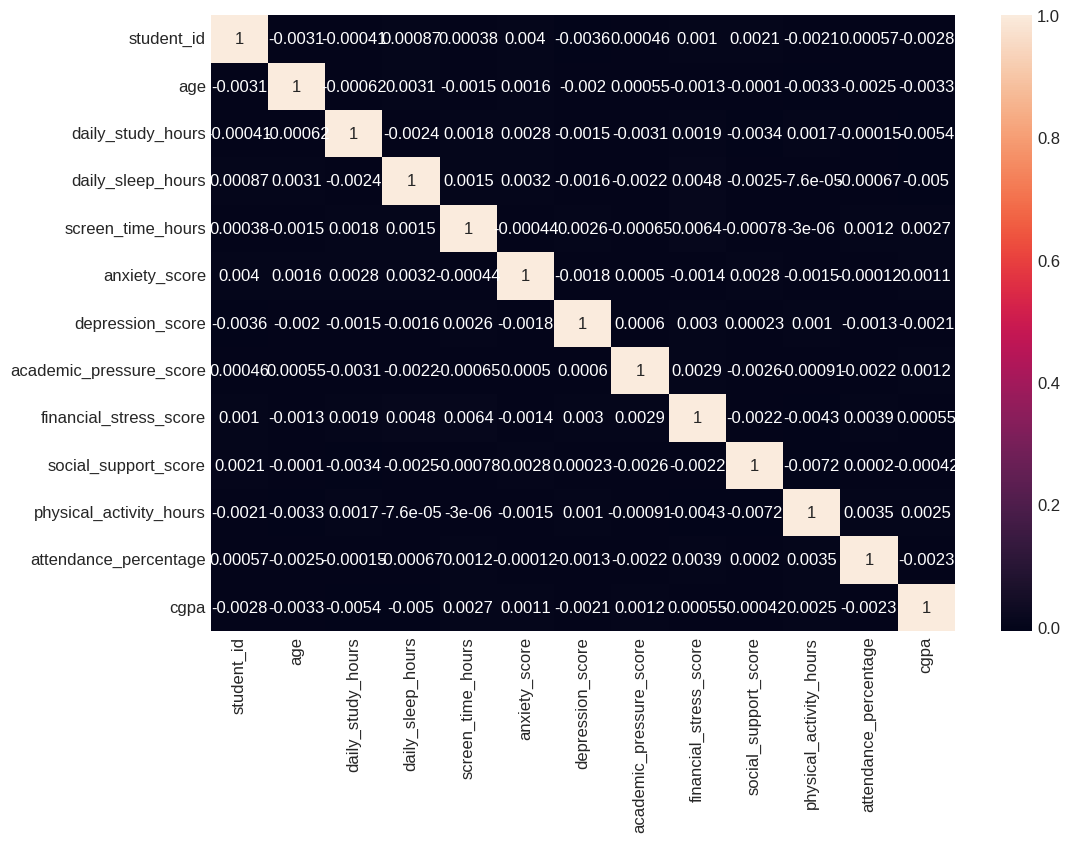

In [131]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.show()

In [132]:
xgb_model.feature_importances_

array([0.04480525, 0.03615062, 0.03447599, 0.03353817, 0.03009816,
       0.0314902 , 0.03373843, 0.04202871, 0.03571583, 0.03649537,
       0.0345992 , 0.0331264 , 0.04019444, 0.02792995, 0.02893527,
       0.02649008, 0.03509838, 0.04905991, 0.04380833, 0.03603818,
       0.03923586, 0.03966108, 0.03005895, 0.03547218, 0.0441569 ,
       0.03431518, 0.03383051, 0.0294525 ], dtype=float32)


```
** burnout_level ile tüm feature’lar ~ 0.00 korelasyon
```

yani:

> ❌ Hiçbir feature burnout’u açıklamıyor

---

# 🧠 Bu ne demek?

Model şunu öğrenmeye çalışıyor:

```text
X → y ilişkisi
```

Ama senin verinde:

```text
X ≈ y ile ilgisiz
```

---

# 🚨 Bu yüzden accuracy ≈ 0.33 çıktı

3 sınıf vardı:

* Low
* Medium
* High

Model hiçbir bilgi bulamayınca:

> “O zaman eşit dağıtayım”

diyor.

Bu da:

```
1 / 3 ≈ 0.33
```

---

# 💡 En önemli sonuç

Bu dataset için:

> ❌ feature engineering yoksa model öğrenemez
> ❌ boosting algoritmaları bile işe yaramaz
> ❌ korelasyon neredeyse sıfır

---

# 🔥 Kritik ML gerçeği (çok önemli)

Bu durum şunu gösterir:

## 1. Problem doğru ama veri yanlış

* problem: burnout prediction
* veri: sentetik / zayıf ilişkili

---

## 2. Model seçimi fark etmez

AdaBoost ❌
XGBoost ❌
RandomForest ❌

Hepsi aynı şeyi yapar:

> random guess

---

# 🧠 Neden böyle dataset üretiyorlar?

Kaggle’da bu tip datasetler genelde:

* eğitim amaçlı
* syntax öğretmek için
* “model çalıştırma” pratiği için

ama:

> gerçek prediction gücü yok

---

# 🚀 Ne yapabilirsin (çok önemli)

## 🔹 1. Binary problem yap

Örnek:

```python id="q3wz1d"
df['burnout_binary'] = (df['burnout_level'] == 'High').astype(int)
```

---

## 🔹 2. Feature engineering ekle

Mesela:

```python id="p7m0sn"
stress_ratio = academic_pressure_score / daily_sleep_hours
```

---

## 🔹 3. interaction features

```python id="x1g9tw"
X['stress_sleep'] = X['academic_pressure_score'] * X['sleep_quality_Good']
```

# 🔥 En önemli çıkarım

Bu sonuç kötü değil — aslında çok değerli:

> “Model kötü değil, veri bilgi içermiyor.”


